# Relative Convergence Analysis

Validates that **res = 48 px/µm** is sufficient by comparing the resonance wavelength shift
Δλ(gap) between res = 48 and res = 128.  
Geometry: r = 3.5 µm, tuner width = 100 nm, n_eff = 2.9933.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.signal import find_peaks
import glob, os

# ── Publication style (matches other notebooks) ──────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "mathtext.fontset": "cm",
})

COL_WIDTH = 3.4
DBL_WIDTH = 7.0
c0 = 299792458

# Gap colormap — dark purple → light blue (matches tuner_gap_analysis)
cmap_gap = LinearSegmentedColormap.from_list(
    "purple_blue",
    [mcolors.to_rgb("#400F77"), mcolors.to_rgb("#A1C9E9")],
    N=256,
)

# Resolution colors (fixed palette)
colors_peak = ["#400F77", "#5B6DAE", "#6D1717"]

def res_color(res, resolutions):
    idx = list(resolutions).index(res)
    return colors_peak[idx % len(colors_peak)]

RES_LS     = {48: "-",  80: "-.",  128: "--"}
RES_MARKER = {48: "o",  80: "^",   128: "s"}
RES_LABEL  = {48: "res = 48 px/µm", 80: "res = 80 px/µm", 128: "res = 128 px/µm"}

def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12


# ── Lorentzian fit for sub-bin peak centers (from archive/tuner_data_analysis) ──
from scipy.optimize import curve_fit

def lorentzian(f, f0, gamma, A, offset):
    return offset + A * gamma**2 / ((f - f0)**2 + gamma**2)

def fit_lorentzian_center(freqs, spectrum, peak_idx, fit_window=0.3):
    """Fit Lorentzian around `peak_idx`, return sub-bin center (THz).
    Falls back to freqs[peak_idx] if the fit fails or drifts outside the window.
    """
    f_peak = freqs[peak_idx]
    mask   = (freqs >= f_peak - fit_window) & (freqs <= f_peak + fit_window)
    if mask.sum() < 5:
        return f_peak
    f_fit = freqs[mask]
    s_fit = spectrum[mask]
    A0      = s_fit.max() - s_fit.min()
    offset0 = s_fit.min()
    gamma0  = 0.05   # 50 GHz, typical WGM
    try:
        popt, _ = curve_fit(lorentzian, f_fit, s_fit,
                            p0=[f_peak, gamma0, A0, offset0],
                            maxfev=2000)
        f0_fit = popt[0]
        if abs(f0_fit - f_peak) > fit_window:
            return f_peak
        return f0_fit
    except Exception:
        return f_peak

def fit_lorentzian_unc(freqs, spectrum, peak_idx, fit_window=0.3):
    """Return 1-sigma uncertainty on f0 from Lorentzian fit (THz). np.nan on failure."""
    f_peak = freqs[peak_idx]
    mask   = (freqs >= f_peak - fit_window) & (freqs <= f_peak + fit_window)
    if mask.sum() < 5:
        return np.nan
    f_fit = freqs[mask]
    s_fit = spectrum[mask]
    A0      = s_fit.max() - s_fit.min()
    offset0 = s_fit.min()
    gamma0  = 0.05
    try:
        popt, pcov = curve_fit(lorentzian, f_fit, s_fit,
                               p0=[f_peak, gamma0, A0, offset0],
                               maxfev=2000)
        if abs(popt[0] - f_peak) > fit_window:
            return np.nan
        return float(np.sqrt(pcov[0, 0]))
    except Exception:
        return np.nan

SAVE = True
DATA_DIR = "data/convergence_relative"
fig_dir  = os.path.join(DATA_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)

In [34]:
# ── Load disk flux spectra ────────────────────────────────────────────────────
RESOLUTIONS = [48, 80, 128]
data = {}

for res in RESOLUTIONS:
    res_dir      = os.path.join(DATA_DIR, f"res_{res}")
    gap_folders  = sorted(glob.glob(os.path.join(res_dir, "tunergap_*um")))
    data[res]    = {}

    for folder in gap_folders:
        gap_um   = float(os.path.basename(folder).replace("tunergap_", "").replace("um", ""))
        gap_nm   = gap_um * 1000
        freqs    = np.load(os.path.join(folder, "freqs_thz.npy"))
        disk     = np.load(os.path.join(folder, "flux_disk.npy"))
        norm     = np.load(os.path.join(folder, "norm_flux.npy"))
        norm_safe = np.where(np.abs(norm) > 1e-20, norm, 1e-20)
        spectrum  = np.abs(disk / norm_safe)
        data[res][gap_nm] = {"freqs": freqs, "spectrum": spectrum}

    print(f"res={res}: gaps = {sorted(data[res].keys())} nm")

all_gaps   = sorted(set.intersection(*[set(data[r].keys()) for r in RESOLUTIONS]))
norm_gap   = Normalize(vmin=min(all_gaps), vmax=max(all_gaps))
print(f"\nCommon gaps: {[f'{g:.0f}' for g in all_gaps]} nm")

res=48: gaps = [5.0, 10.0, 20.0, 35.0, 50.0, 70.0] nm
res=80: gaps = [5.0, 10.0, 20.0, 35.0, 50.0, 70.0] nm
res=128: gaps = [5.0, 10.0, 20.0, 35.0, 50.0, 70.0] nm

Common gaps: ['5', '10', '20', '35', '50', '70'] nm


## Spectra — res = 48 px/µm

/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


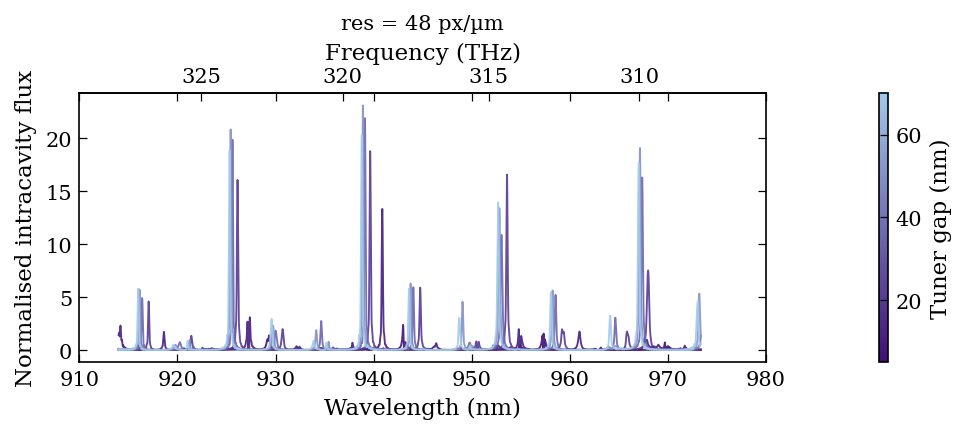

In [35]:
WL_MIN, WL_MAX = 910, 980

def plot_spectra(res, ax):
    for gap_nm in all_gaps:
        d    = data[res][gap_nm]
        wl   = thz_to_nm(d["freqs"])
        mask = (wl >= WL_MIN) & (wl <= WL_MAX)
        ax.plot(wl[mask][::-1], d["spectrum"][mask][::-1],
                color=cmap_gap(norm_gap(gap_nm)), lw=0.9, alpha=0.9)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Normalised intracavity flux")
    ax.set_xlim(WL_MIN, WL_MAX)
    ax2 = ax.secondary_xaxis("top", functions=(nm_to_thz, thz_to_nm))
    ax2.set_xlabel("Frequency (THz)")

fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))
plot_spectra(48, ax)
ax.set_title("res = 48 px/µm", fontsize=10)

sm   = plt.cm.ScalarMappable(cmap=cmap_gap, norm=norm_gap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.12, aspect=30)
cbar.set_label("Tuner gap (nm)")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_res48.{ext}"))
plt.show()

## Spectra — res = 80 px/µm

/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


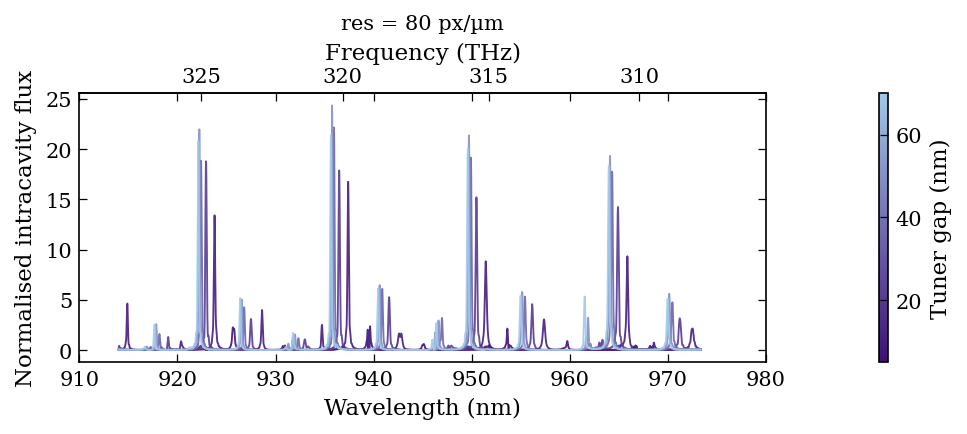

In [36]:
fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))
plot_spectra(80, ax)
ax.set_title("res = 80 px/µm", fontsize=10)

sm   = plt.cm.ScalarMappable(cmap=cmap_gap, norm=norm_gap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.12, aspect=30)
cbar.set_label("Tuner gap (nm)")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_res80.{ext}"))
plt.show()

## Spectra — res = 128 px/µm

/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


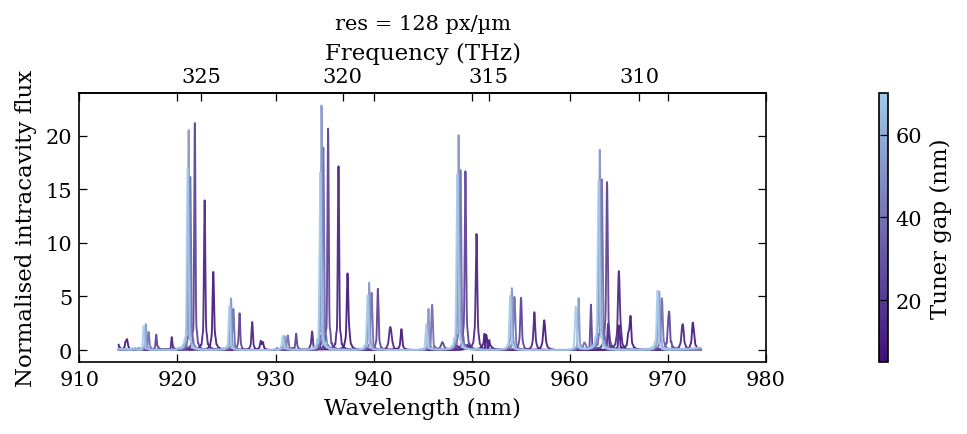

In [37]:
fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))
plot_spectra(128, ax)
ax.set_title("res = 128 px/µm", fontsize=10)

sm   = plt.cm.ScalarMappable(cmap=cmap_gap, norm=norm_gap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.12, aspect=30)
cbar.set_label("Tuner gap (nm)")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"spectra_res128.{ext}"))
plt.show()

## Resonance tracking

Most-prominent peak within 315–327 THz, seeded at the largest gap and followed to smaller gaps.

In [38]:
SEARCH_MIN_THz   = 310.0
SEARCH_MAX_THz   = 330.0
FOLLOW_WINDOW    = 2.5    # THz

def track_resonance(res_data, gaps_large_to_small):
    tracked  = {}
    seed_f   = None
    for gap_nm in gaps_large_to_small:
        d        = res_data[gap_nm]
        freqs    = d["freqs"]
        spectrum = d["spectrum"]
        df       = freqs[1] - freqs[0]
        peaks, props = find_peaks(spectrum, prominence=0.3, distance=int(0.3 / df))
        if len(peaks) == 0:
            tracked[gap_nm] = np.nan
            continue
        pf    = freqs[peaks]
        proms = props["prominences"]
        if seed_f is None:
            m = (pf >= SEARCH_MIN_THz) & (pf <= SEARCH_MAX_THz)
            chosen = pf[m][np.argmax(proms[m])] if np.any(m) else np.nan
        else:
            close = np.abs(pf - seed_f) < FOLLOW_WINDOW
            if np.any(close):
                chosen = pf[close][np.argmax(proms[close])]
            else:
                m = (pf >= SEARCH_MIN_THz) & (pf <= SEARCH_MAX_THz)
                chosen = pf[m][np.argmax(proms[m])] if np.any(m) else np.nan
        seed_f          = chosen if not np.isnan(chosen) else seed_f
        tracked[gap_nm] = thz_to_nm(chosen) if not np.isnan(chosen) else np.nan
    return tracked

gaps_desc  = sorted(all_gaps, reverse=True)
resonances = {res: track_resonance(data[res], gaps_desc) for res in RESOLUTIONS}

print(f"{'Gap (nm)':>10} | {'λ res=48 (nm)':>15} | {'λ res=128 (nm)':>16}")
print("-" * 47)
for g in sorted(all_gaps):
    w48  = resonances[48].get(g, np.nan)
    w128 = resonances[128].get(g, np.nan)
    print(f"{g:>10.0f} | {w48:>15.3f} | {w128:>16.3f}")

  Gap (nm) |   λ res=48 (nm) |   λ res=128 (nm)
-----------------------------------------------
         5 |         943.000 |          923.649
        10 |         940.879 |          922.770
        20 |         939.646 |          921.769
        35 |         939.114 |          921.303
        50 |         938.906 |          921.139
        70 |         938.789 |          921.042


## Tuning curve — resonance wavelength vs tuner gap

/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
/tmp/ipykernel_1750301/185884992.py:54: RuntimeWarning: divide by zero encountered in divide
  def thz_to_nm(f): return c0 / (f * 1e12) * 1e9


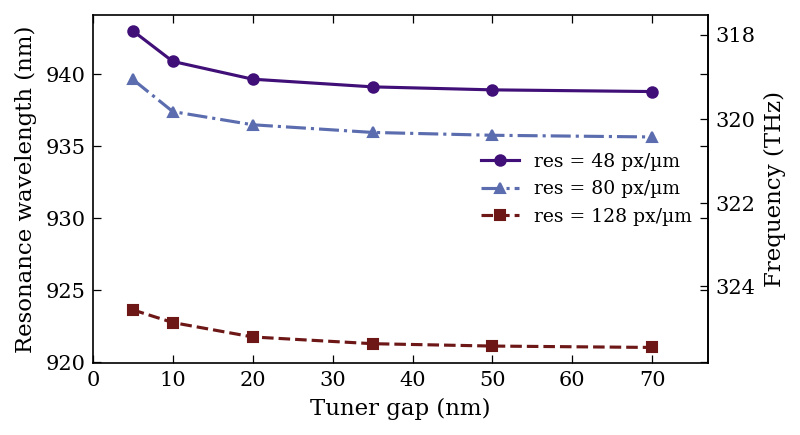

In [39]:
fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, 3))

for res in RESOLUTIONS:
    g_arr = np.array(sorted(resonances[res].keys()))
    w_arr = np.array([resonances[res][g] for g in g_arr])
    v     = ~np.isnan(w_arr)
    ax.plot(g_arr[v], w_arr[v],
            color=res_color(res, RESOLUTIONS), ls=RES_LS[res],
            marker=RES_MARKER[res], markersize=5, lw=1.5,
            label=RES_LABEL[res])

ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel("Resonance wavelength (nm)")
ax.set_xlim(0, max(all_gaps) * 1.1)
ax.legend()

ax2 = ax.secondary_yaxis("right", functions=(nm_to_thz, thz_to_nm))
ax2.set_ylabel("Frequency (THz)")

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"tuning_curve.{ext}"))
plt.show()

## Resonance shift Δλ relative to largest gap (50 nm)

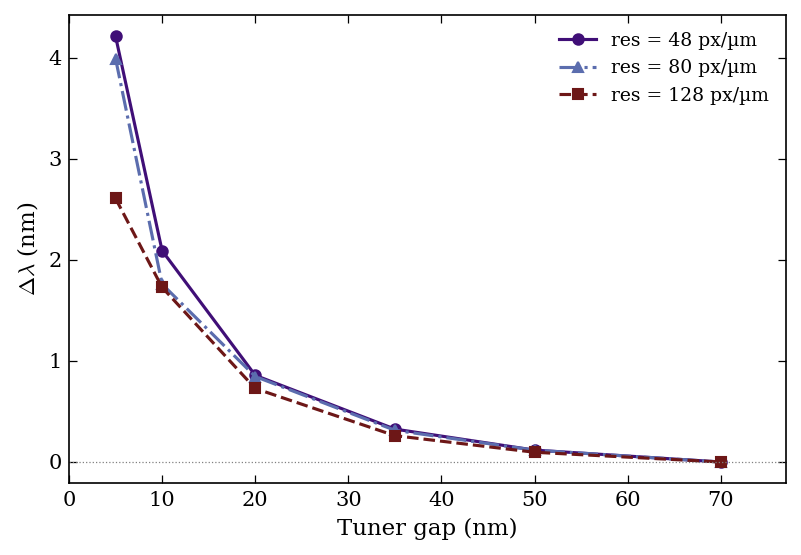

In [40]:
ref_gap = max(all_gaps)

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, 3.8))

for res in RESOLUTIONS:
    g_arr  = np.array(sorted(resonances[res].keys()))
    w_arr  = np.array([resonances[res][g] for g in g_arr])
    ref_wl = resonances[res][ref_gap]
    delta  = w_arr - ref_wl
    v      = ~np.isnan(delta)
    ax.plot(g_arr[v], delta[v],
            color=res_color(res, RESOLUTIONS), ls=RES_LS[res],
            marker=RES_MARKER[res], markersize=5, lw=1.5,
            label=RES_LABEL[res])

ax.axhline(0, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel(r"$\Delta\lambda$ (nm)")
ax.set_xlim(0, ref_gap * 1.1)
ax.legend()

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"resonance_shift.{ext}"))
plt.show()

## Convergence error |Δλ₄₈ − Δλ₁₂₈|

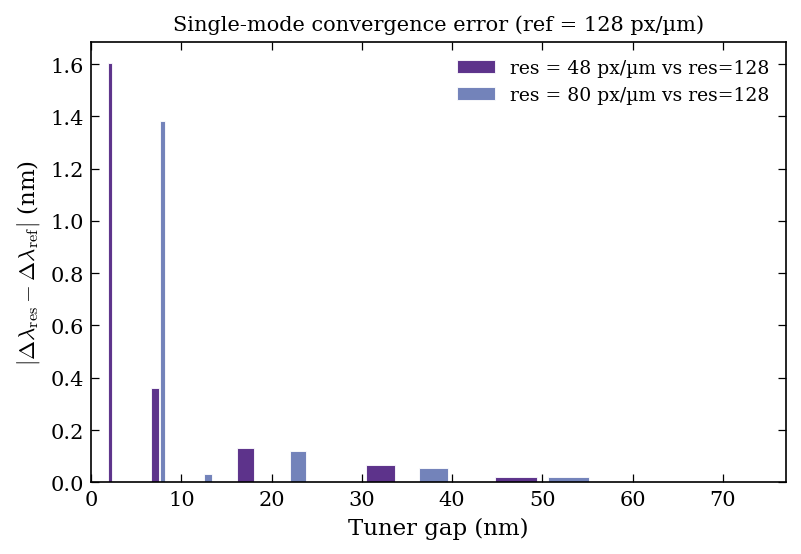


  Gap (nm) |    Δλ_48 |  |diff| |    Δλ_80 |  |diff| |   Δλ_128
-----------------------------------------------------------
         5 |    4.211 |   1.604 |    3.990 |   1.383 |    2.607
        10 |    2.090 |   0.362 |    1.759 |   0.032 |    1.728
        20 |    0.857 |   0.130 |    0.846 |   0.119 |    0.727
        35 |    0.325 |   0.065 |    0.314 |   0.053 |    0.260
        50 |    0.118 |   0.021 |    0.117 |   0.021 |    0.096
        70 |    0.000 |   0.000 |    0.000 |   0.000 |    0.000


In [41]:
# Single-mode convergence error vs highest resolution
ref_res   = max(RESOLUTIONS)
other_res = [r for r in RESOLUTIONS if r != ref_res]

ref_wl_ref = resonances[ref_res][ref_gap]
d_ref      = np.array([resonances[ref_res][g] - ref_wl_ref for g in g_arr])

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, 3.8))

bar_width = (max(all_gaps) / len(all_gaps)) * 0.25
offsets   = np.linspace(-(len(other_res)-1)/2, (len(other_res)-1)/2, len(other_res))

for res, offset in zip(other_res, offsets):
    ref_wl = resonances[res][ref_gap]
    d_res  = np.array([resonances[res][g] - ref_wl for g in g_arr])
    err    = np.abs(d_res - d_ref)
    valid  = ~np.isnan(err)
    ax.bar(g_arr[valid] + offset * bar_width * 2,
           err[valid],
           width=bar_width * g_arr[valid] / g_arr[valid].mean(),
           color=res_color(res, RESOLUTIONS), alpha=0.85,
           edgecolor="white", linewidth=0.5,
           label=f"{RES_LABEL[res]} vs res={ref_res}")

ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel(r"$|\Delta\lambda_\mathrm{res} - \Delta\lambda_\mathrm{ref}|$ (nm)")
ax.set_xlim(0, ref_gap * 1.1)
ax.set_title(f"Single-mode convergence error (ref = {ref_res} px/µm)", fontsize=10)
ax.legend()

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"convergence_error.{ext}"))
plt.show()

print(f"\n{'Gap (nm)':>10}", end="")
for res in other_res:
    print(f" | {'Δλ_'+str(res):>8} | {'|diff|':>7}", end="")
print(f" | {'Δλ_'+str(ref_res):>8}")
print("-" * (10 + len(other_res) * 19 + 11))
for g in g_arr:
    ref_wl_ref = resonances[ref_res][ref_gap]
    d_r = resonances[ref_res][g] - ref_wl_ref
    print(f"{g:>10.0f}", end="")
    for res in other_res:
        ref_wl = resonances[res][ref_gap]
        d_s = resonances[res][g] - ref_wl
        print(f" | {d_s:>8.3f} | {abs(d_s - d_r):>7.3f}", end="")
    print(f" | {d_r:>8.3f}")

## Averaged resonance shift across multiple modes

Track the **three most prominent WGMs** in the search window independently,
compute Δλ for each mode, then average.  
Averaging over several modes reduces sensitivity to any single mode being
poorly resolved and gives a more robust estimate of the overall tuning shift.  
Individual mode shifts are shown as faint lines for context; bold lines are the averages.

In [42]:
N_MODES = 4
OUTLIER_NSIGMA = 1.0   # z-score threshold; max z-score for 3 pts is √2 ≈ 1.41
MIN_SEED_SEP   = 1.0   # THz — minimum separation between seed peaks
DEDUP_TOL_NM   = 1.0   # nm  — two modes closer than this at ref gap are duplicates

def track_multi(res_data, gaps_large_to_small, n_modes=N_MODES):
    """Track N most prominent peaks seeded at the largest gap, each followed independently."""
    seed_gap = gaps_large_to_small[0]
    d        = res_data[seed_gap]
    freqs    = d["freqs"];  spectrum = d["spectrum"]
    df       = freqs[1] - freqs[0]
    peaks, props = find_peaks(spectrum, prominence=0.3, distance=int(0.3 / df))
    pf = np.array([fit_lorentzian_center(freqs, spectrum, idx) for idx in peaks])
    proms = props["prominences"]

    in_win = (pf >= SEARCH_MIN_THz) & (pf <= SEARCH_MAX_THz)
    pf_w   = pf[in_win];  proms_w = proms[in_win]

    order      = np.argsort(proms_w)[::-1]
    seed_freqs = []
    for idx in order:
        f_cand = pf_w[idx]
        if all(abs(f_cand - f_kept) >= MIN_SEED_SEP for f_kept in seed_freqs):
            seed_freqs.append(f_cand)
        if len(seed_freqs) == n_modes:
            break
    seed_freqs = np.array(seed_freqs)

    current_f = seed_freqs.copy()
    tracked   = {i: {} for i in range(len(seed_freqs))}
    fit_uncs  = {i: {} for i in range(len(seed_freqs))}

    for gap_nm in gaps_large_to_small:
        d     = res_data[gap_nm]
        freqs = d["freqs"];  spectrum = d["spectrum"]
        df    = freqs[1] - freqs[0]
        peaks, props = find_peaks(spectrum, prominence=0.3, distance=int(0.3 / df))
        pf    = np.array([fit_lorentzian_center(freqs, spectrum, idx) for idx in peaks])
        proms = props["prominences"]

        for i in range(len(seed_freqs)):
            cf = current_f[i]
            if np.isnan(cf) or len(peaks) == 0:
                tracked[i][gap_nm] = np.nan
                continue
            close = np.abs(pf - cf) < FOLLOW_WINDOW
            if np.any(close):
                chosen_idx_local  = np.argmax(proms[close])
                chosen            = pf[close][chosen_idx_local]
                # uncertainty: look up original peak index
                orig_idx          = peaks[np.where(close)[0][chosen_idx_local]]
                fit_uncs[i][gap_nm] = fit_lorentzian_unc(freqs, spectrum, orig_idx)
                current_f[i]      = chosen
                tracked[i][gap_nm] = thz_to_nm(chosen)
            else:
                tracked[i][gap_nm] = np.nan
                fit_uncs[i][gap_nm] = np.nan
                current_f[i]       = np.nan

    # Post-tracking deduplication: discard modes that converge to the same
    # wavelength at the reference gap as a higher-prominence mode.
    seen_wl = []
    clean   = {}
    new_idx = 0
    for i in sorted(tracked.keys()):
        wl_ref = tracked[i].get(seed_gap, np.nan)
        if np.isnan(wl_ref):
            continue
        if all(abs(wl_ref - w) >= DEDUP_TOL_NM for w in seen_wl):
            clean[new_idx] = tracked[i]
            seen_wl.append(wl_ref)
            new_idx += 1

    # Map clean's new indices back to fit_uncs
    clean_uncs = {}
    orig_keys = [i for i in sorted(tracked.keys())
                 if not np.isnan(tracked[i].get(seed_gap, np.nan))]
    kept = []
    seen_rebuild = []
    for i in orig_keys:
        wl_ref = tracked[i].get(seed_gap, np.nan)
        if all(abs(wl_ref - w) >= DEDUP_TOL_NM for w in seen_rebuild):
            kept.append(i)
            seen_rebuild.append(wl_ref)
    for new_k, orig_k in enumerate(kept):
        clean_uncs[new_k] = fit_uncs[orig_k]

    return clean, clean_uncs


def avg_shift(multi_tracked, ref_gap, nsigma=OUTLIER_NSIGMA):
    """Per-mode Δλ, mean and std after outlier removal."""
    gaps = sorted(next(iter(multi_tracked.values())).keys())
    per_mode = {}
    for i, mode_dict in multi_tracked.items():
        ref_wl = mode_dict.get(ref_gap, np.nan)
        per_mode[i] = {g: mode_dict[g] - ref_wl for g in gaps}

    avg = {};  std = {};  outlier_log = []

    for g in gaps:
        vals     = np.array([per_mode[i][g] for i in per_mode
                             if not np.isnan(per_mode[i][g])])
        mode_ids = [i for i in per_mode if not np.isnan(per_mode[i][g])]

        if len(vals) >= 3:
            s = np.std(vals, ddof=0)
            if s > 1e-10:
                z     = np.abs(vals - np.mean(vals)) / s
                worst = np.argmax(z)
                if z[worst] > nsigma:
                    outlier_log.append(
                        f"  gap={g:.0f} nm: dropped mode {mode_ids[worst]+1} "
                        f"(Δλ={vals[worst]:.3f} nm, z={z[worst]:.2f})"
                    )
                    vals = np.delete(vals, worst)

        avg[g] = np.mean(vals) if len(vals) > 0 else np.nan
        std[g] = np.std(vals, ddof=0) if len(vals) > 1 else 0.0

    return per_mode, avg, std, outlier_log


# ── Run for all resolutions ───────────────────────────────────────────────────
multi     = {}
fit_unc_all = {}
for res in RESOLUTIONS:
    multi[res], fit_unc_all[res] = track_multi(data[res], gaps_desc)
per_modes = {}
avgs      = {}
stds      = {}
logs      = {}

for res in RESOLUTIONS:
    per_modes[res], avgs[res], stds[res], logs[res] = avg_shift(multi[res], ref_gap)

for res in RESOLUTIONS:
    n = len(multi[res])
    seeds = [multi[res][i][ref_gap] for i in range(n)]
    print(f"res={res}: {n} unique modes at {ref_gap:.0f} nm gap: "
          + "  ".join(f"M{i+1}={s:.2f} nm" for i, s in enumerate(seeds)))

print()
for res in RESOLUTIONS:
    print(f"res={res} outliers removed:")
    print("\n".join(logs[res]) if logs[res] else "  none")

g_arr = np.array(sorted(all_gaps))
header = f"{'Gap (nm)':>10}"
for res in RESOLUTIONS:
    header += f" | {'avg_' + str(res):>8} | {'±std':>5}"
header += f" | {'ref diff 48':>11} | {'ref diff 80':>11}"
print(f"\n{header}")
print("-" * (10 + len(RESOLUTIONS) * 17 + 26))
ref_res = max(RESOLUTIONS)
for g in g_arr:
    row = f"{g:>10.0f}"
    for res in RESOLUTIONS:
        row += f" | {avgs[res][g]:>8.3f} | {stds[res][g]:>5.3f}"
    for res in RESOLUTIONS[:-1]:   # diff vs highest res
        diff = abs(avgs[res][g] - avgs[ref_res][g])
        row += f" | {diff:>11.3f}"
    print(row)

# ── Fit quality summary ───────────────────────────────────────────────────────
print("\nLorentzian fit uncertainty (1σ) per resolution:")
for res in RESOLUTIONS:
    all_uncs_nm = []
    for mode_uncs in fit_unc_all[res].values():
        for g, u_thz in mode_uncs.items():
            if not np.isnan(u_thz):
                wl = thz_to_nm(data[res][g]["freqs"][0])   # approx wavelength for conversion
                # Δλ = (λ²/c) × Δf  — use ref wavelength ~940 nm
                u_nm = u_thz * 1e12 * (940e-9)**2 / 3e8 * 1e9
                all_uncs_nm.append(u_nm)
    if all_uncs_nm:
        print(f"  res={res}: mean={np.mean(all_uncs_nm):.4f} nm  "
              f"max={np.max(all_uncs_nm):.4f} nm  "
              f"(vs avg shift error ~{np.nanmean([abs(avgs[res][g]) for g in sorted(avgs[res])]):.3f} nm)")

res=48: 4 unique modes at 70 nm gap: M1=938.79 nm  M2=925.32 nm  M3=967.02 nm  M4=952.69 nm
res=80: 4 unique modes at 70 nm gap: M1=935.64 nm  M2=922.13 nm  M3=949.60 nm  M4=963.97 nm
res=128: 4 unique modes at 70 nm gap: M1=921.04 nm  M2=934.57 nm  M3=948.54 nm  M4=962.94 nm

res=48 outliers removed:
  gap=5 nm: dropped mode 3 (Δλ=-9.725 nm, z=1.73)
  gap=10 nm: dropped mode 3 (Δλ=-6.051 nm, z=1.73)
  gap=20 nm: dropped mode 3 (Δλ=0.952 nm, z=1.38)
  gap=35 nm: dropped mode 2 (Δλ=0.288 nm, z=1.57)
  gap=50 nm: dropped mode 2 (Δλ=0.104 nm, z=1.64)
res=80 outliers removed:
  gap=5 nm: dropped mode 4 (Δλ=-4.245 nm, z=1.73)
  gap=10 nm: dropped mode 2 (Δλ=1.652 nm, z=1.48)
  gap=20 nm: dropped mode 2 (Δλ=0.787 nm, z=1.40)
  gap=35 nm: dropped mode 2 (Δλ=0.276 nm, z=1.59)
  gap=50 nm: dropped mode 2 (Δλ=0.102 nm, z=1.64)
res=128 outliers removed:
  gap=5 nm: dropped mode 3 (Δλ=8.848 nm, z=1.73)
  gap=10 nm: dropped mode 4 (Δλ=2.068 nm, z=1.38)
  gap=20 nm: dropped mode 1 (Δλ=0.728 nm, z=1.

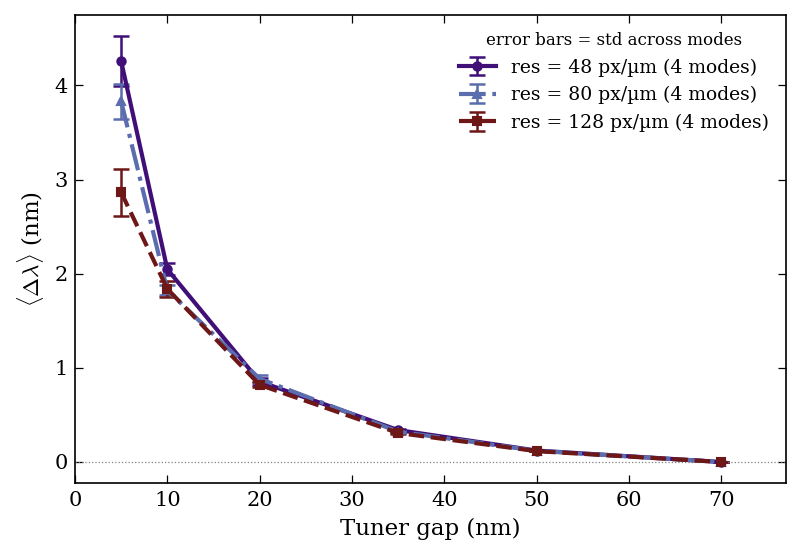

In [43]:
fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, 3.8))

for res in RESOLUTIONS:
    d_s = np.array([avgs[res][g] for g in g_arr])
    e_s = np.array([stds[res][g] for g in g_arr])
    v   = ~np.isnan(d_s)
    n_modes_used = len(multi[res])
    ax.errorbar(g_arr[v], d_s[v], yerr=e_s[v],
                color=res_color(res, RESOLUTIONS), ls=RES_LS[res],
                marker=RES_MARKER[res], markersize=4, lw=2.0,
                capsize=4, capthick=1.2, elinewidth=1.2,
                label=f"{RES_LABEL[res]} ({n_modes_used} modes)")

ax.axhline(0, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel(r"$\langle\Delta\lambda\rangle$ (nm)")
ax.set_xlim(0, ref_gap * 1.1)
ax.legend(title="error bars = std across modes", title_fontsize=8)

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"avg_shift_comparison.{ext}"))
plt.show()

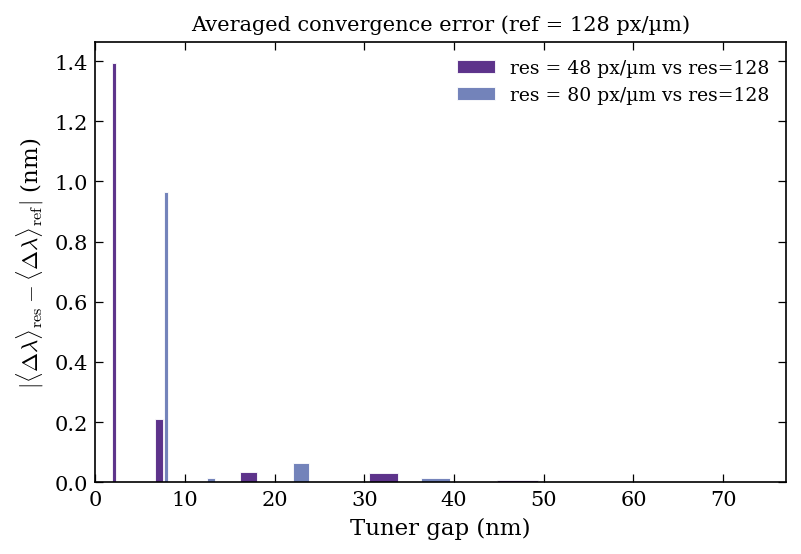


Average convergence error vs res=128 px/µm:
  Gap (nm) |       res = 48 px/µm |       res = 80 px/µm
----------------------------------------------------------
         5 |              1.3932 nm |              0.9665 nm | 
        10 |              0.2087 nm |              0.0129 nm | 
        20 |              0.0347 nm |              0.0650 nm | 
        35 |              0.0308 nm |              0.0142 nm | 
        50 |              0.0062 nm |              0.0033 nm | 
        70 |              0.0000 nm |              0.0000 nm | 


In [44]:
# ── Plot: |⟨Δλ⟩_res − ⟨Δλ⟩_ref| for each non-reference resolution ────────────
# Uses the highest resolution as the reference ground truth.
ref_res    = max(RESOLUTIONS)
other_res  = [r for r in RESOLUTIONS if r != ref_res]

fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.6, 3.8))

bar_width   = (max(all_gaps) / len(all_gaps)) * 0.25
offsets     = np.linspace(-(len(other_res)-1)/2, (len(other_res)-1)/2, len(other_res))

for res, offset in zip(other_res, offsets):
    avg_err = np.array([
        abs(avgs[res][g] - avgs[ref_res][g])
        if not (np.isnan(avgs[res][g]) or np.isnan(avgs[ref_res][g])) else np.nan
        for g in g_arr
    ])
    valid = ~np.isnan(avg_err)
    ax.bar(g_arr[valid] + offset * bar_width * 2,
           avg_err[valid],
           width=bar_width * g_arr[valid] / g_arr[valid].mean(),
           color=res_color(res, RESOLUTIONS), alpha=0.85,
           edgecolor="white", linewidth=0.5,
           label=f"{RES_LABEL[res]} vs res={ref_res}")

ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel(r"$|\langle\Delta\lambda\rangle_\mathrm{res} - \langle\Delta\lambda\rangle_\mathrm{ref}|$ (nm)")
ax.set_xlim(0, ref_gap * 1.1)
ax.set_title(f"Averaged convergence error (ref = {ref_res} px/µm)", fontsize=10)
ax.legend()

plt.tight_layout()
if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"avg_convergence_error.{ext}"))
plt.show()

print("\nAverage convergence error vs res=" + str(ref_res) + " px/µm:")
print(f"{'Gap (nm)':>10} | " + " | ".join(f"{RES_LABEL[r]:>20}" for r in other_res))
print("-" * (12 + 23 * len(other_res)))
for g in g_arr:
    row = f"{g:>10.0f} | "
    for r in other_res:
        if not (np.isnan(avgs[r][g]) or np.isnan(avgs[ref_res][g])):
            err = abs(avgs[r][g] - avgs[ref_res][g])
            row += f"{err:>19.4f} nm | "
        else:
            row += f"{'nan':>19} | "
    print(row)
